In [29]:
from pathlib import Path
import neurokit2 as nk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [30]:
BASE_PATH = Path("../../data/processed/dalia")
PATIENTS = [f"S{i}" for i in range(1, 16)]  # S1 to S15

print(f"Base path: {BASE_PATH}")
print(f"Patients to analyze: {PATIENTS}")
print(f"Total patients: {len(PATIENTS)}")


def load_patient_bvp(patient_id: str, base_path: Path) -> pd.DataFrame:
    """
    Load bvp for a specific patient from wrist_BVP.csv.

    Parameters
    ----------
    patient_id : str
        Patient ID (e.g., 'S1', 'S2', etc.)
    base_path : Path
        Base path to the DALIA dataset

    Returns
    -------
    pd.DataFrame
        DataFrame containing the wrist_BVP.csv data
    """
    bvp_path = base_path / patient_id / "wrist/wrist_BVP.csv"

    if not bvp_path.exists():
        raise FileNotFoundError(f"BVP file not found: {bvp_path}")

    # Read CSV file - assumes first column contains bvp values
    df = pd.read_csv(bvp_path)
    return df


Base path: ..\..\data\processed\dalia
Patients to analyze: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15']
Total patients: 15


In [31]:
def extract_random_chunk(bvp_data: pd.DataFrame, chunk_size: int = 640) -> tuple:
    """
    Extract a random chunk of specified size from BVP data.

    Parameters
    ----------
    bvp_data : pd.DataFrame
        DataFrame containing BVP values
    chunk_size : int, optional
        Size of the chunk to extract (default: 640)

    Returns
    -------
    tuple
        (chunk_data, start_index) - the chunk and its starting index
    """
    total_length = len(bvp_data)

    if chunk_size > total_length:
        print(f"Warning: Chunk size ({chunk_size}) is larger than data length "
              f"({total_length}). Using full data.")
        return bvp_data, 0

    # Pick a random starting position
    start_idx = np.random.randint(0, total_length - chunk_size + 1)
    end_idx = start_idx + chunk_size

    chunk = bvp_data.iloc[start_idx:end_idx]
    return chunk, start_idx


def plot_bvp_chunk(patient_id: str, chunk: pd.DataFrame, start_idx: int):
    """
    Plot a chunk of BVP data for a patient.

    Parameters
    ----------
    patient_id : str
        Patient ID for display purposes
    chunk : pd.DataFrame
        BVP data chunk to plot
    start_idx : int
        Starting index of the chunk in the original data
    """
    fig, ax = plt.subplots(figsize=(14, 4))

    # Get the first column (BVP values)
    bvp_values = chunk.iloc[:, 0].values

    ax.plot(bvp_values, linewidth=0.8, color='steelblue')
    ax.set_title(f'BVP Data - Patient {patient_id} '
                 f'(Records {start_idx} to {start_idx + len(chunk)})',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Sample Index (within chunk)', fontsize=12)
    ax.set_ylabel('BVP Value', fontsize=12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [32]:
print("Functions defined successfully ✓")


Functions defined successfully ✓


In [33]:
# Extract and store random ECG chunks for all patients
CHUNK_SIZE = 640

# Dictionary to store chunks and metadata for each patient
patient_chunks = {}

print(f"\nExtracting random {CHUNK_SIZE}-sample chunks for each patient...")
print("=" * 70)

for patient_id in PATIENTS:
    try:
        print(f"\nProcessing {patient_id}...")

        # Load BVP data
        bvp_data = load_patient_bvp(patient_id, BASE_PATH)
        print(f"  Total BVP samples: {len(bvp_data)}")

        # Extract random chunk
        chunk, start_idx = extract_random_chunk(bvp_data, chunk_size=CHUNK_SIZE)
        print(f"  Random chunk extracted: indices {start_idx} to {start_idx + len(chunk)}")

        # Store chunk and metadata
        patient_chunks[patient_id] = {
            'chunk': chunk,
            'start_idx': start_idx,
            'end_idx': start_idx + len(chunk),
            'chunk_size': len(chunk),
            'total_samples': len(bvp_data)
        }
        print(f"  ✓ Chunk stored in patient_chunks['{patient_id}']")

    except FileNotFoundError as e:
        print(f"  ✗ Error: {e}")
    except Exception as e:
        print(f"  ✗ Unexpected error: {e}")

print("\n" + "=" * 70)
print(f"All patients processed ✓")
print(f"Total chunks stored: {len(patient_chunks)}")
print(f"\nAccess chunks using: patient_chunks['PATIENT_ID']['chunk']")



Extracting random 640-sample chunks for each patient...

Processing S1...
  Total BVP samples: 589568
  Random chunk extracted: indices 119932 to 120572
  ✓ Chunk stored in patient_chunks['S1']

Processing S2...
  Total BVP samples: 525120
  Random chunk extracted: indices 504952 to 505592
  ✓ Chunk stored in patient_chunks['S2']

Processing S3...
  Total BVP samples: 559424
  Random chunk extracted: indices 555157 to 555797
  ✓ Chunk stored in patient_chunks['S3']

Processing S4...
  Total BVP samples: 585600
  Random chunk extracted: indices 212756 to 213396
  ✓ Chunk stored in patient_chunks['S4']

Processing S5...
  Total BVP samples: 595520
  Random chunk extracted: indices 373084 to 373724
  ✓ Chunk stored in patient_chunks['S5']

Processing S6...
  Total BVP samples: 336000
  Random chunk extracted: indices 35593 to 36233
  ✓ Chunk stored in patient_chunks['S6']

Processing S7...
  Total BVP samples: 597952
  Random chunk extracted: indices 372292 to 372932
  ✓ Chunk stored in 

Plotting all patient BVP chunks...

Plotting S1...


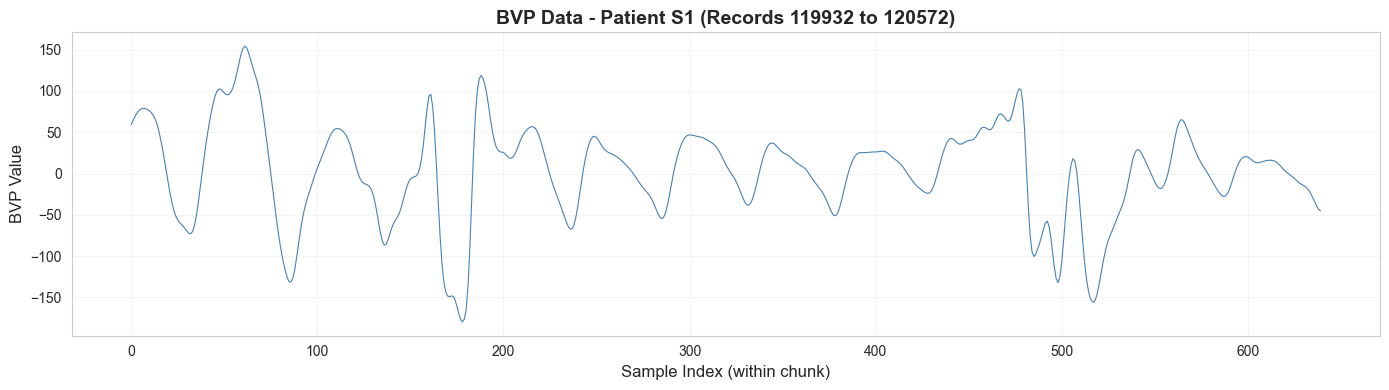


Plotting S2...


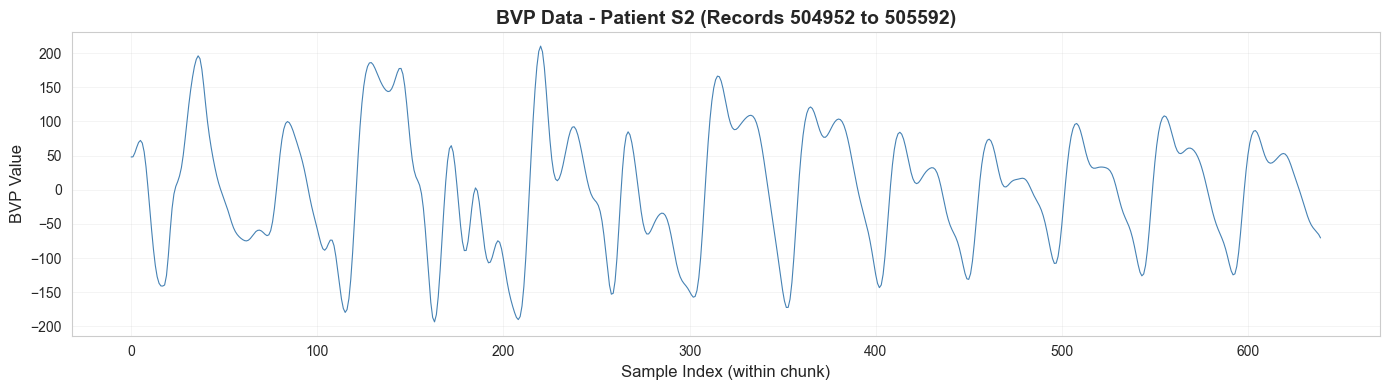


Plotting S3...


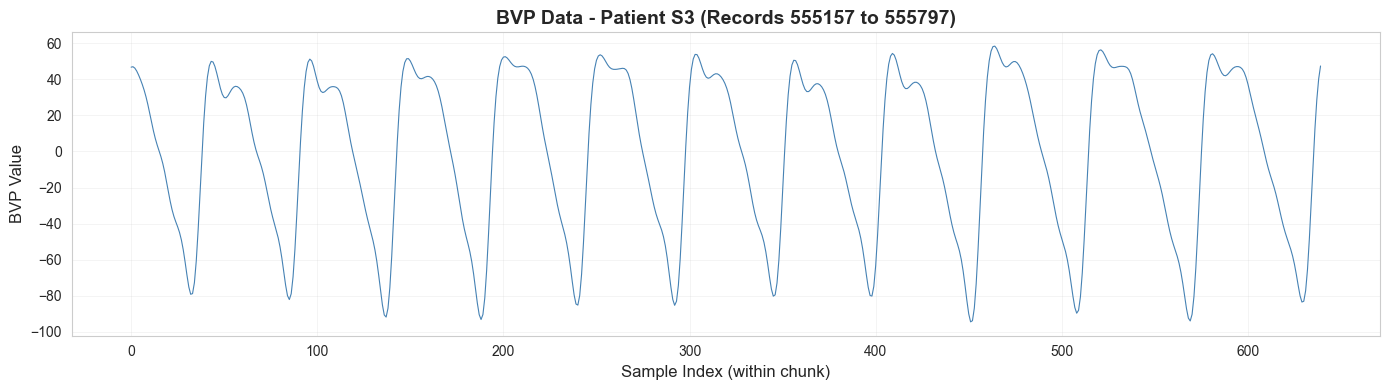


Plotting S4...


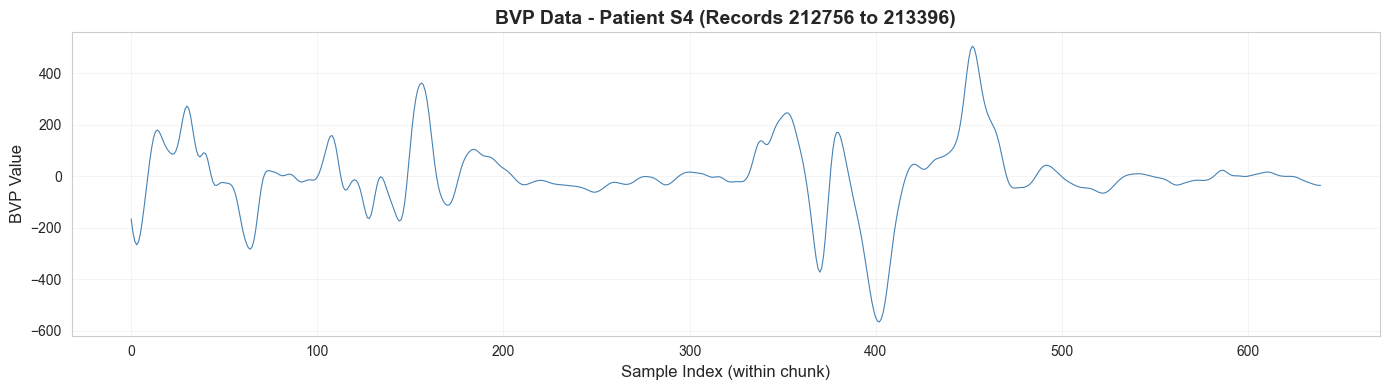


Plotting S5...


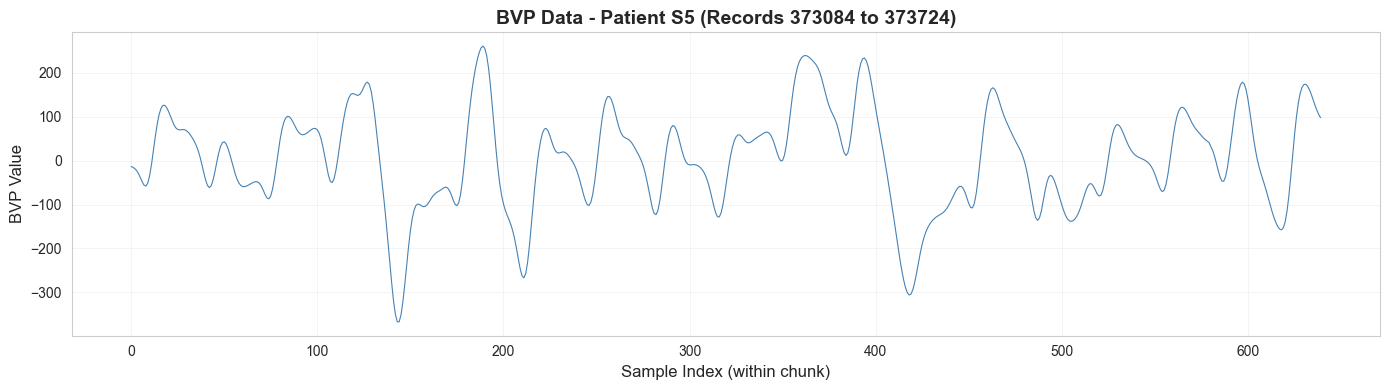


Plotting S6...


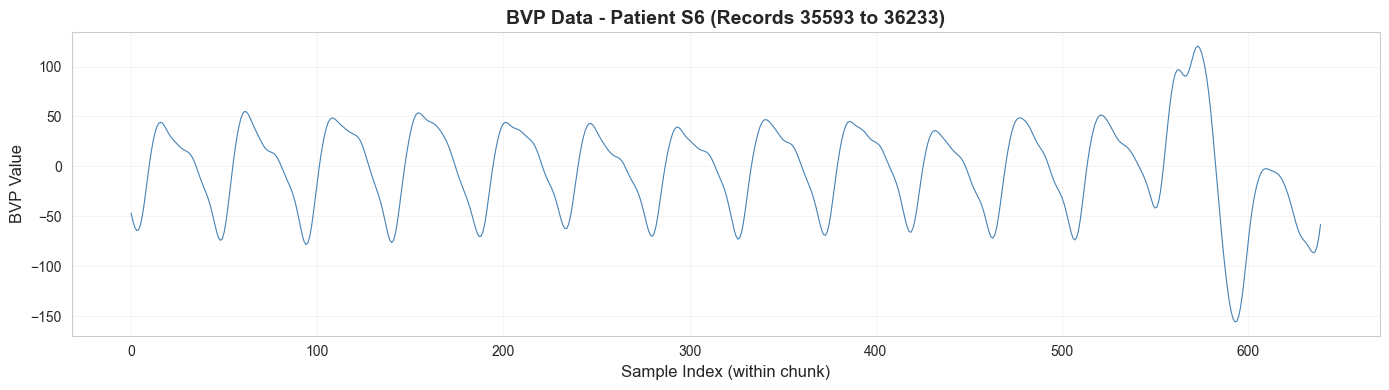


Plotting S7...


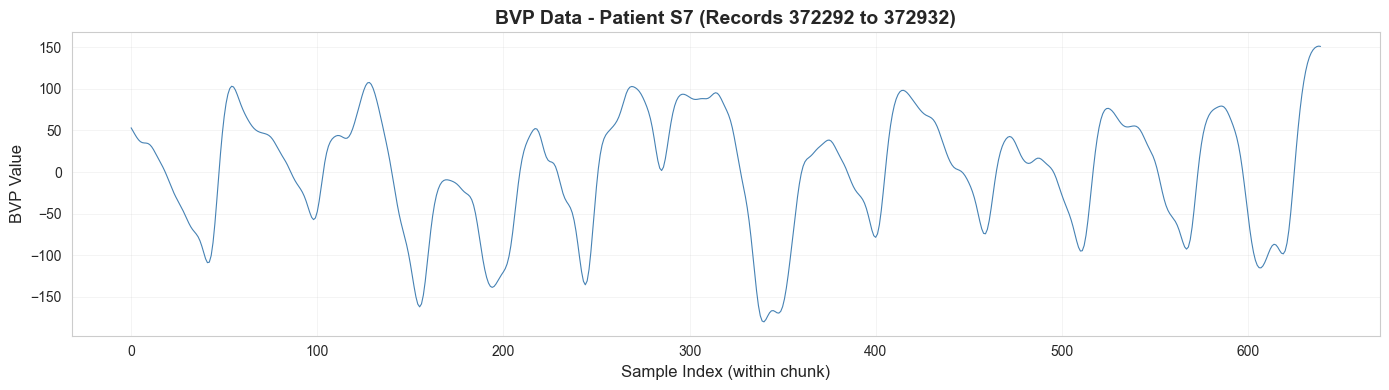


Plotting S8...


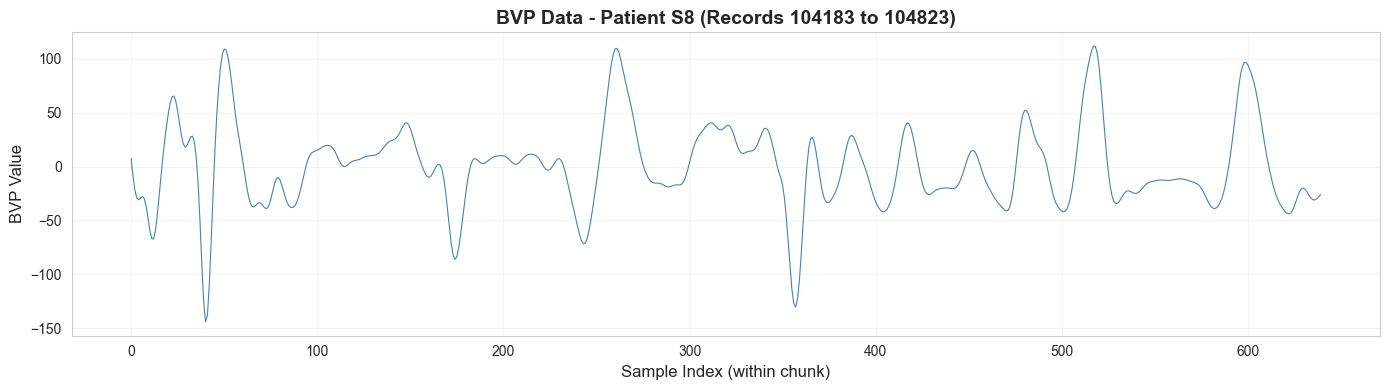


Plotting S9...


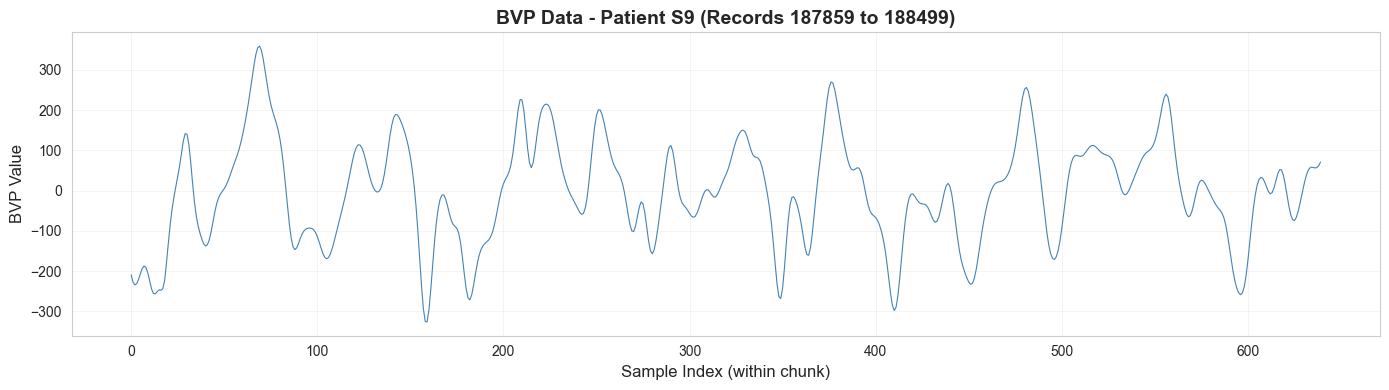


Plotting S10...


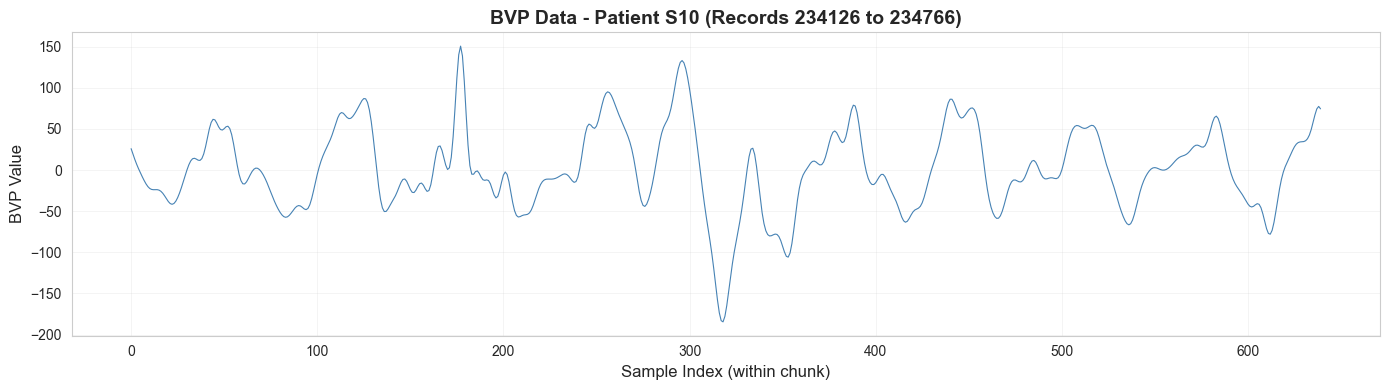


Plotting S11...


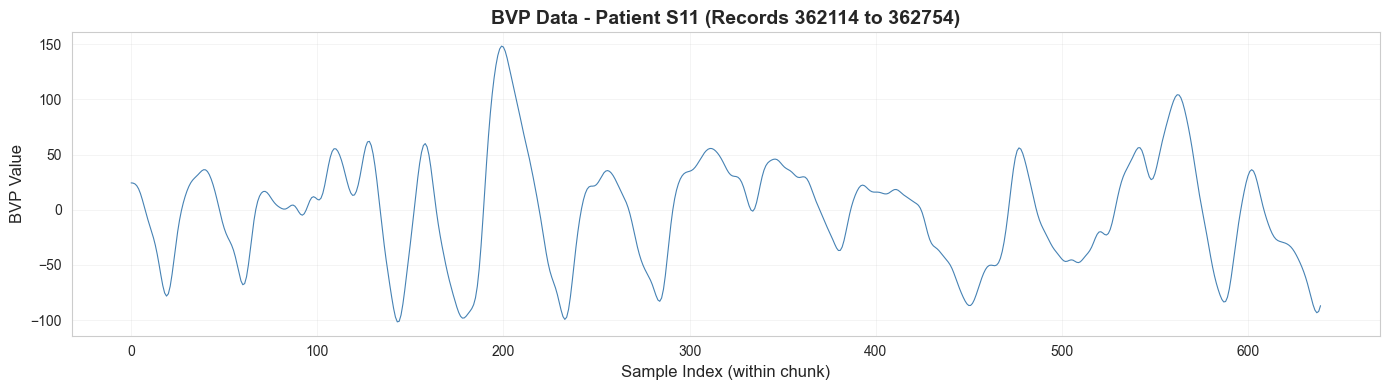


Plotting S12...


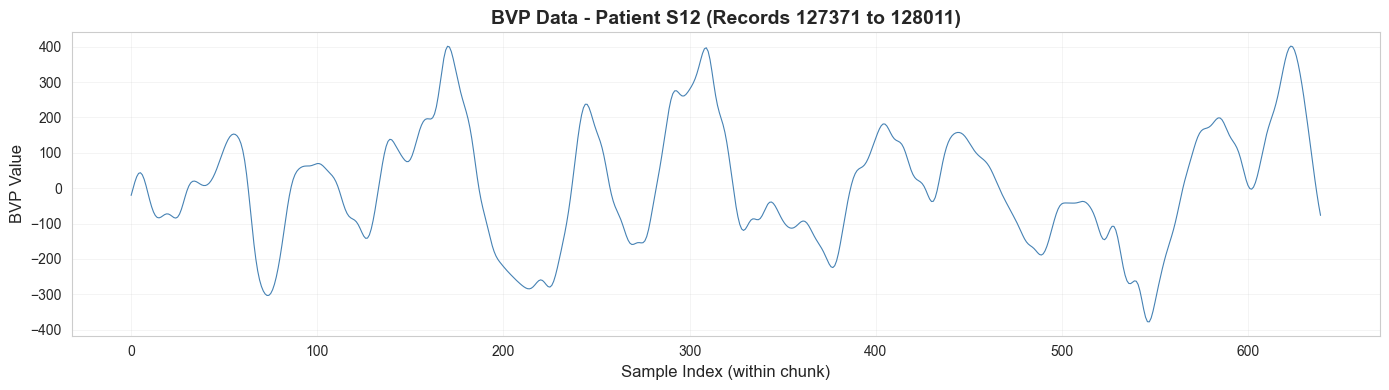


Plotting S13...


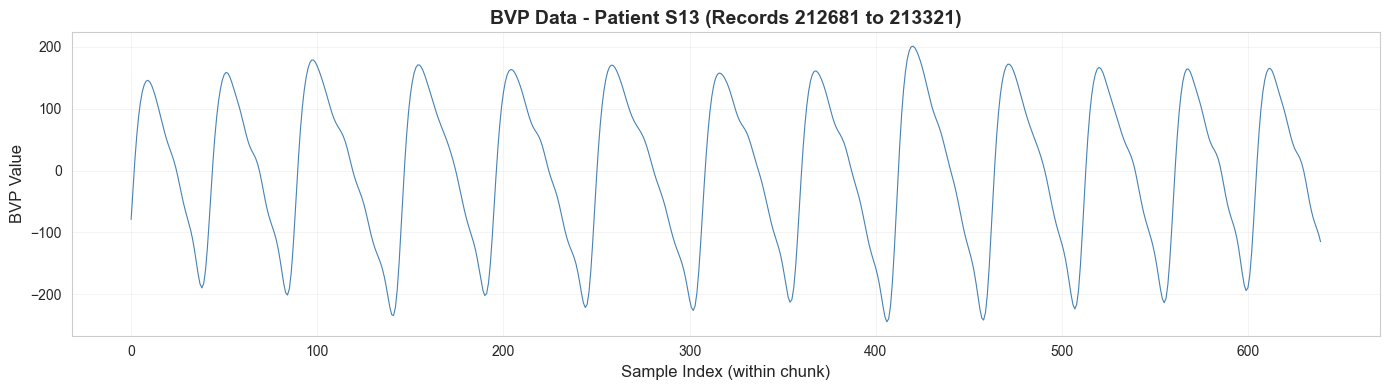


Plotting S14...


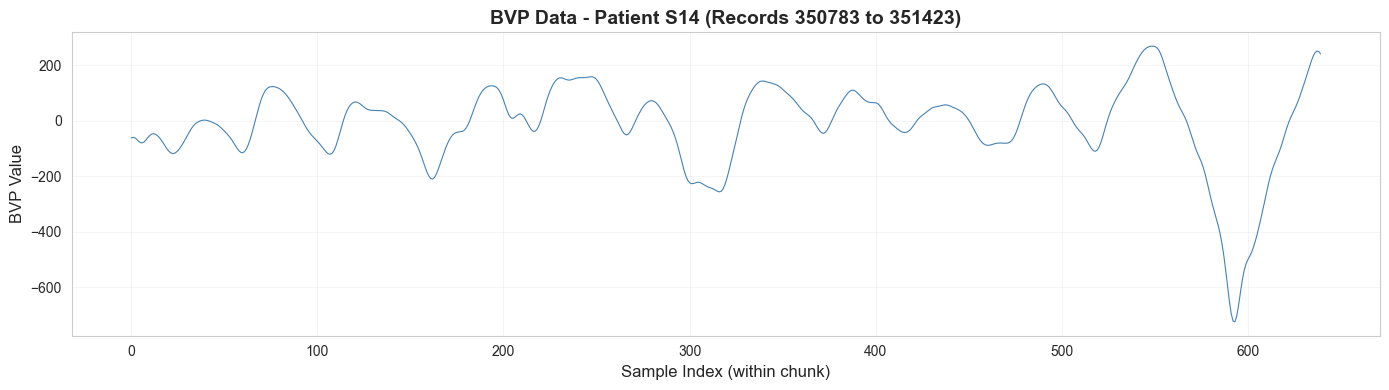


Plotting S15...


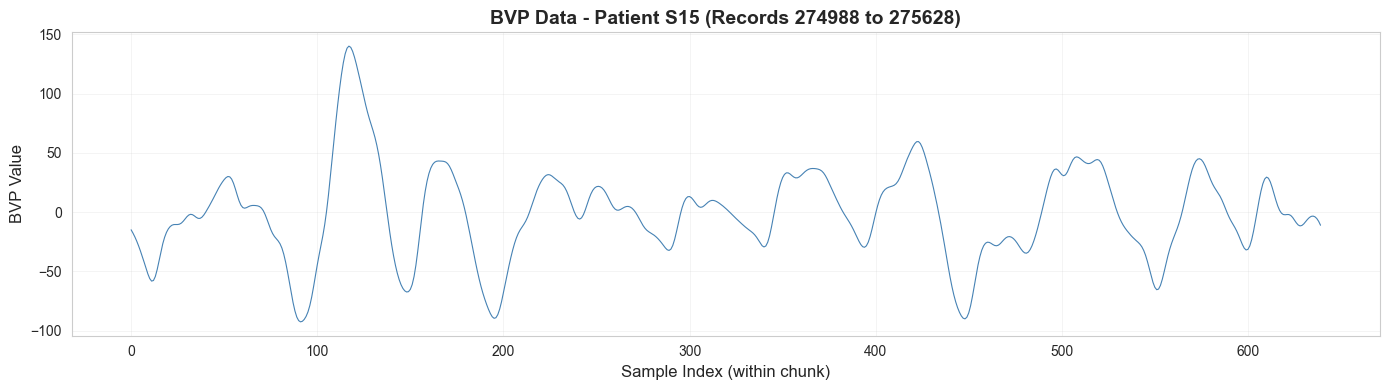


All plots displayed ✓


In [34]:
# Plot all stored chunks
print("Plotting all patient BVP chunks...")
print("=" * 70)

for patient_id, data in patient_chunks.items():
    print(f"\nPlotting {patient_id}...")
    plot_bvp_chunk(patient_id, data['chunk'], data['start_idx'])

print("\n" + "=" * 70)
print("All plots displayed ✓")

Comparing raw vs cleaned BVP for all patients...

Processing S1...


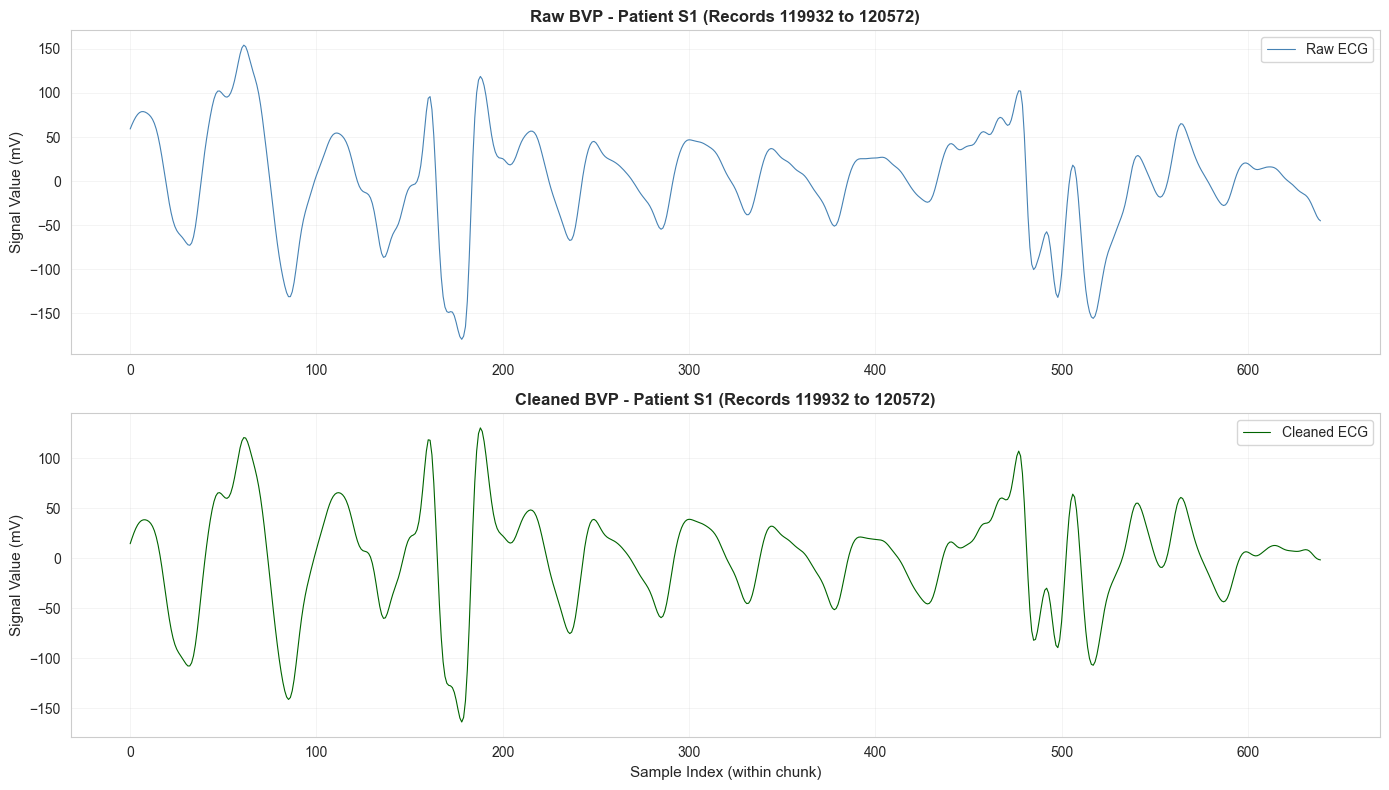

  Raw BVP - Mean: 1.7628, Std: 58.1582, Min: -179.5300, Max: 154.2800
  Cleaned BVP - Mean: -0.0275, Std: 51.2717, Min: -163.6391, Max: 130.0868

Processing S2...


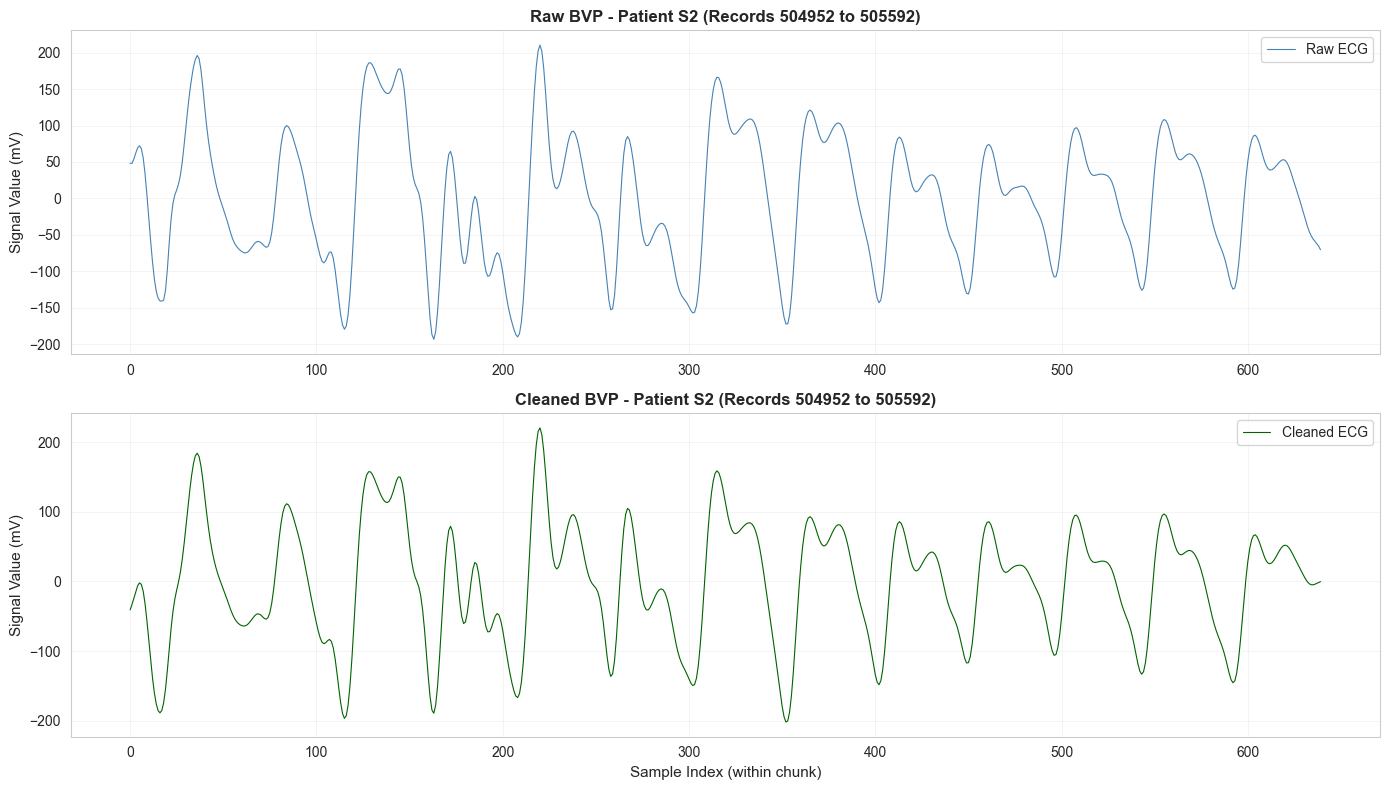

  Raw BVP - Mean: 1.7800, Std: 88.2946, Min: -193.4900, Max: 210.3800
  Cleaned BVP - Mean: -1.3295, Std: 84.5983, Min: -201.6449, Max: 220.4357

Processing S3...


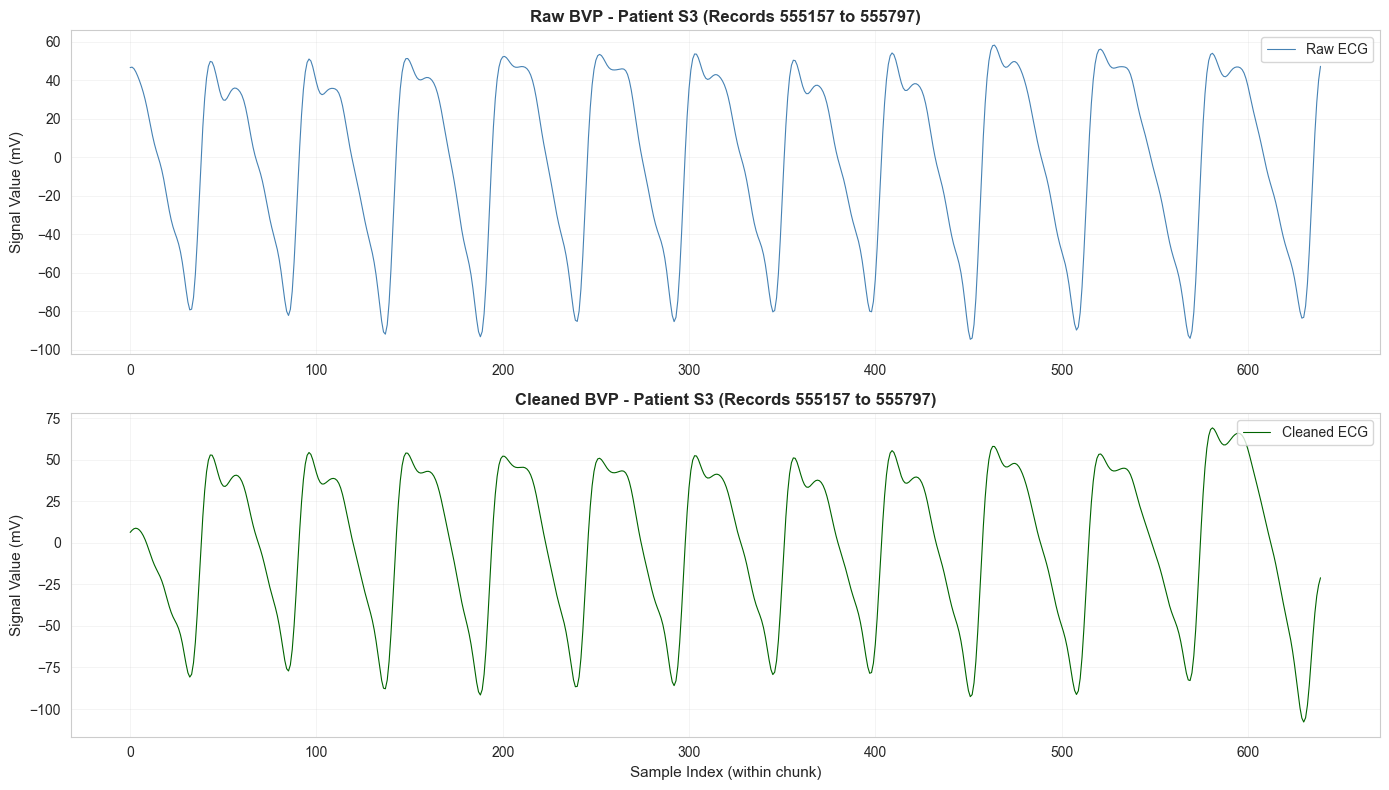

  Raw BVP - Mean: -0.7271, Std: 44.9690, Min: -94.4500, Max: 58.3600
  Cleaned BVP - Mean: -1.0661, Std: 45.8321, Min: -107.8231, Max: 69.0915

Processing S4...


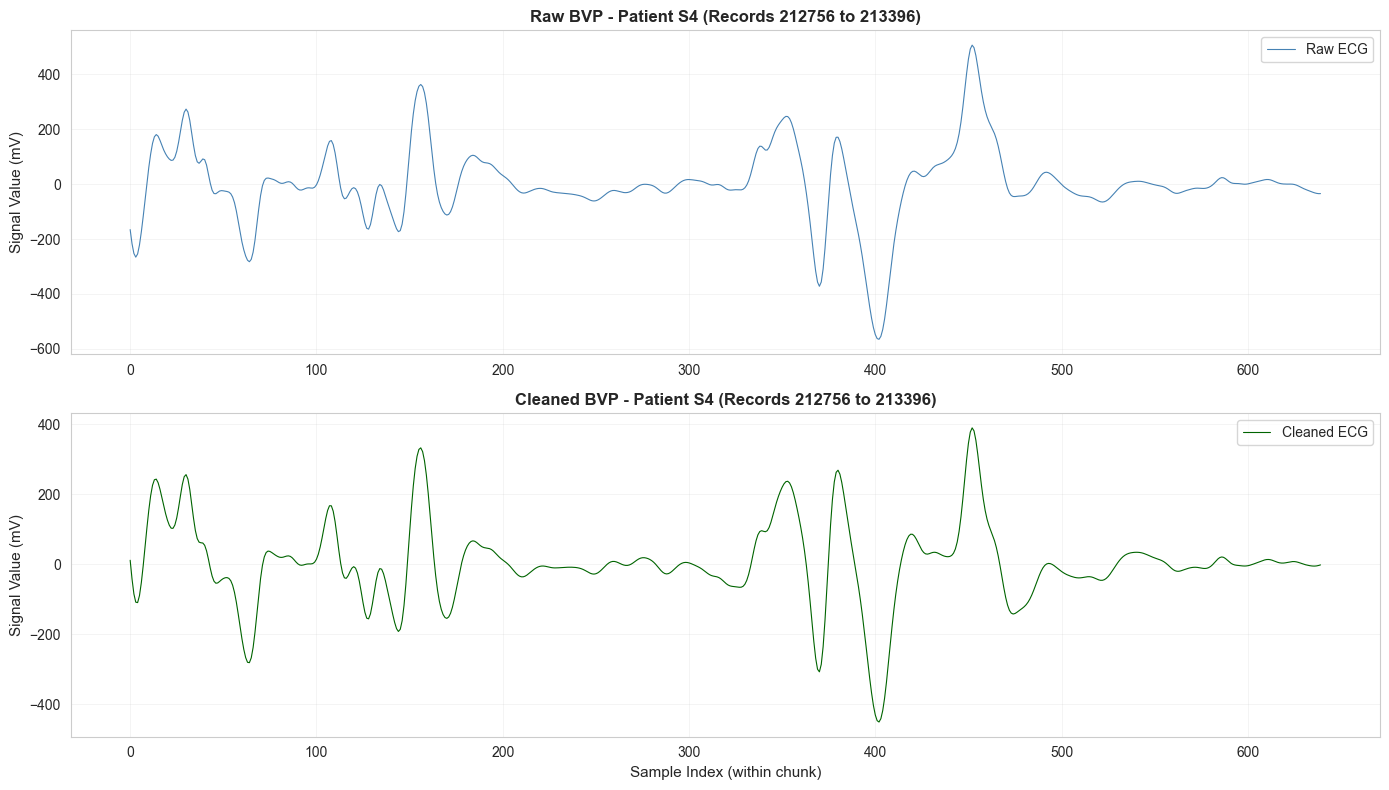

  Raw BVP - Mean: 1.0746, Std: 135.4785, Min: -564.9800, Max: 505.5000
  Cleaned BVP - Mean: 3.4275, Std: 115.4199, Min: -450.0684, Max: 389.5074

Processing S5...


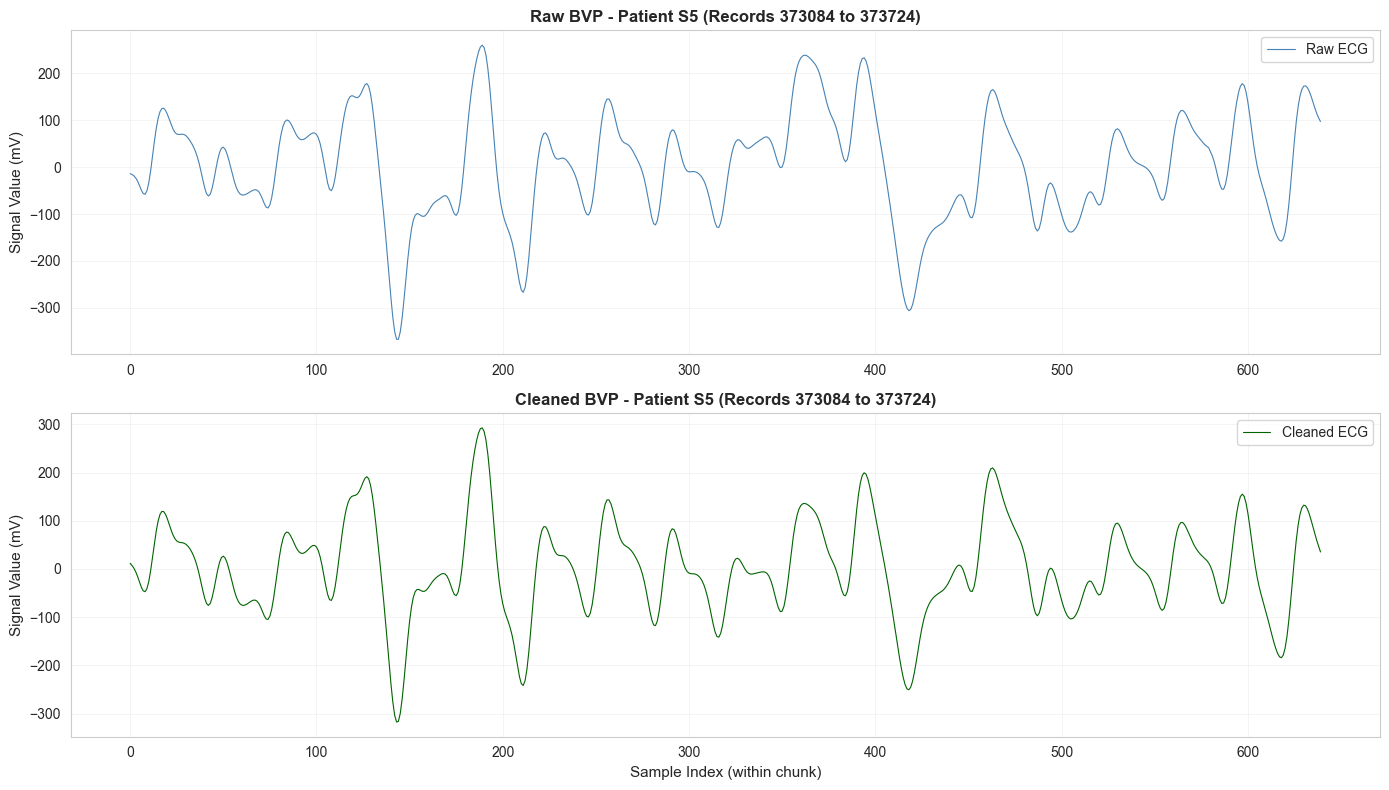

  Raw BVP - Mean: 2.2098, Std: 113.7377, Min: -366.9700, Max: 260.3200
  Cleaned BVP - Mean: 1.3193, Std: 98.6863, Min: -317.6601, Max: 292.7604

Processing S6...


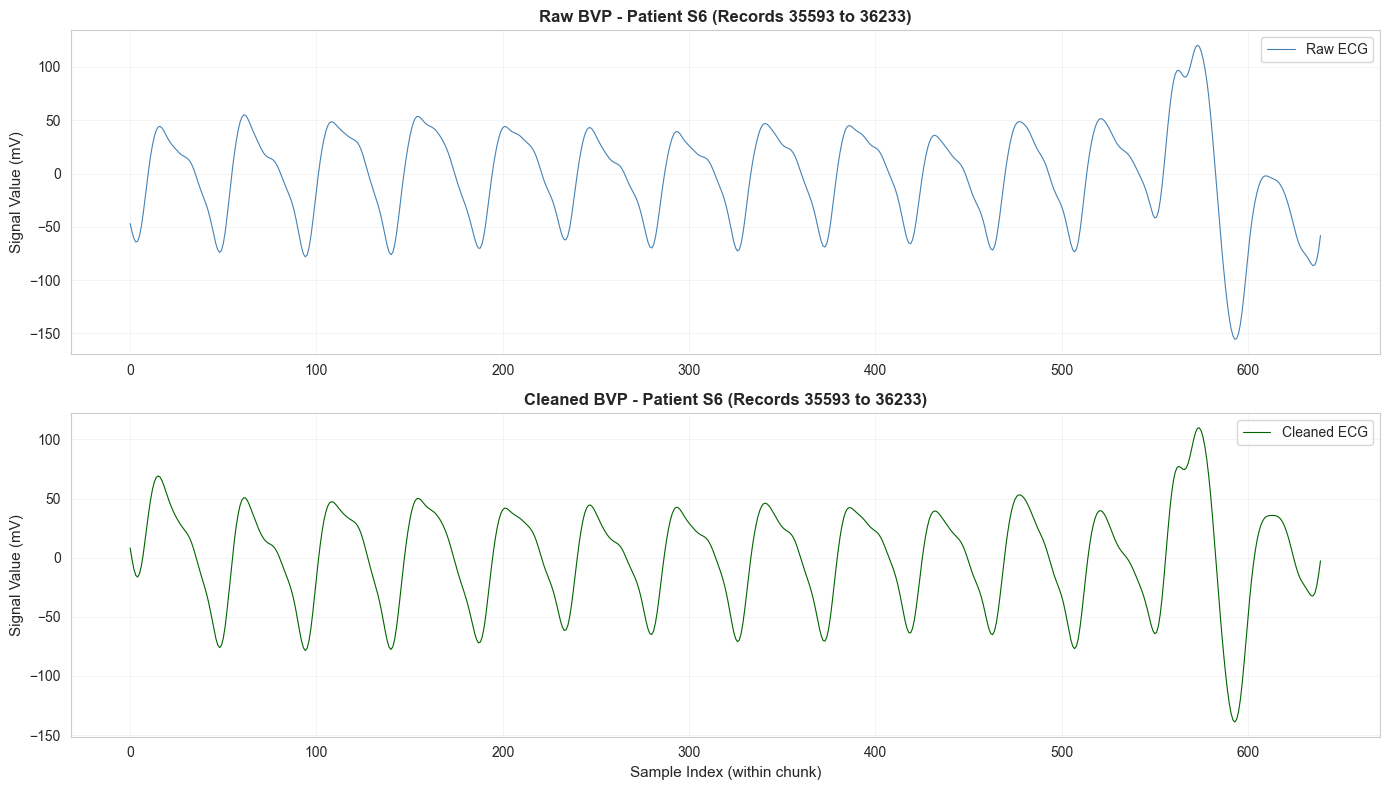

  Raw BVP - Mean: -2.2272, Std: 45.2240, Min: -155.4900, Max: 120.4000
  Cleaned BVP - Mean: 0.4676, Std: 42.2830, Min: -138.9105, Max: 109.7000

Processing S7...


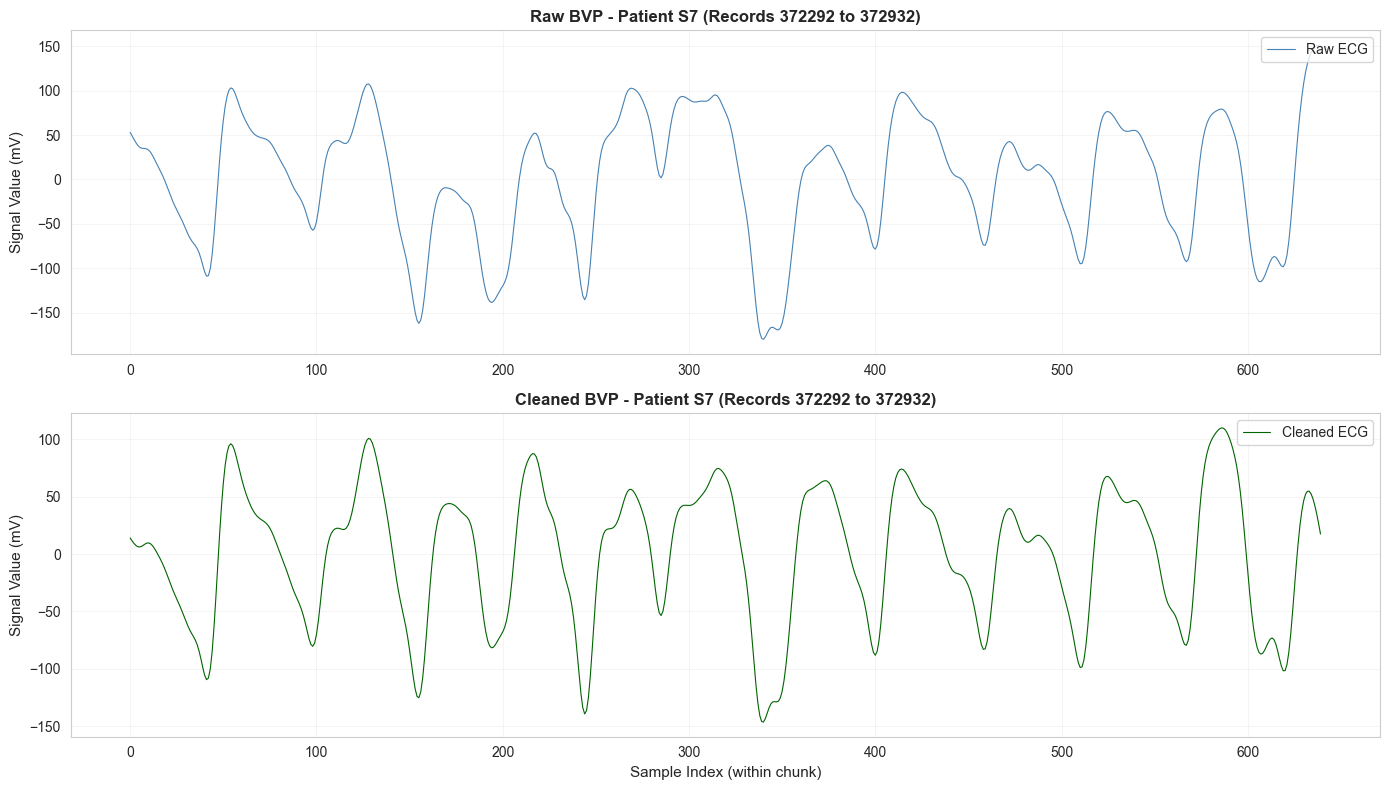

  Raw BVP - Mean: 0.8797, Std: 70.4177, Min: -180.0100, Max: 151.3400
  Cleaned BVP - Mean: -0.3565, Std: 58.6850, Min: -146.2448, Max: 109.8355

Processing S8...


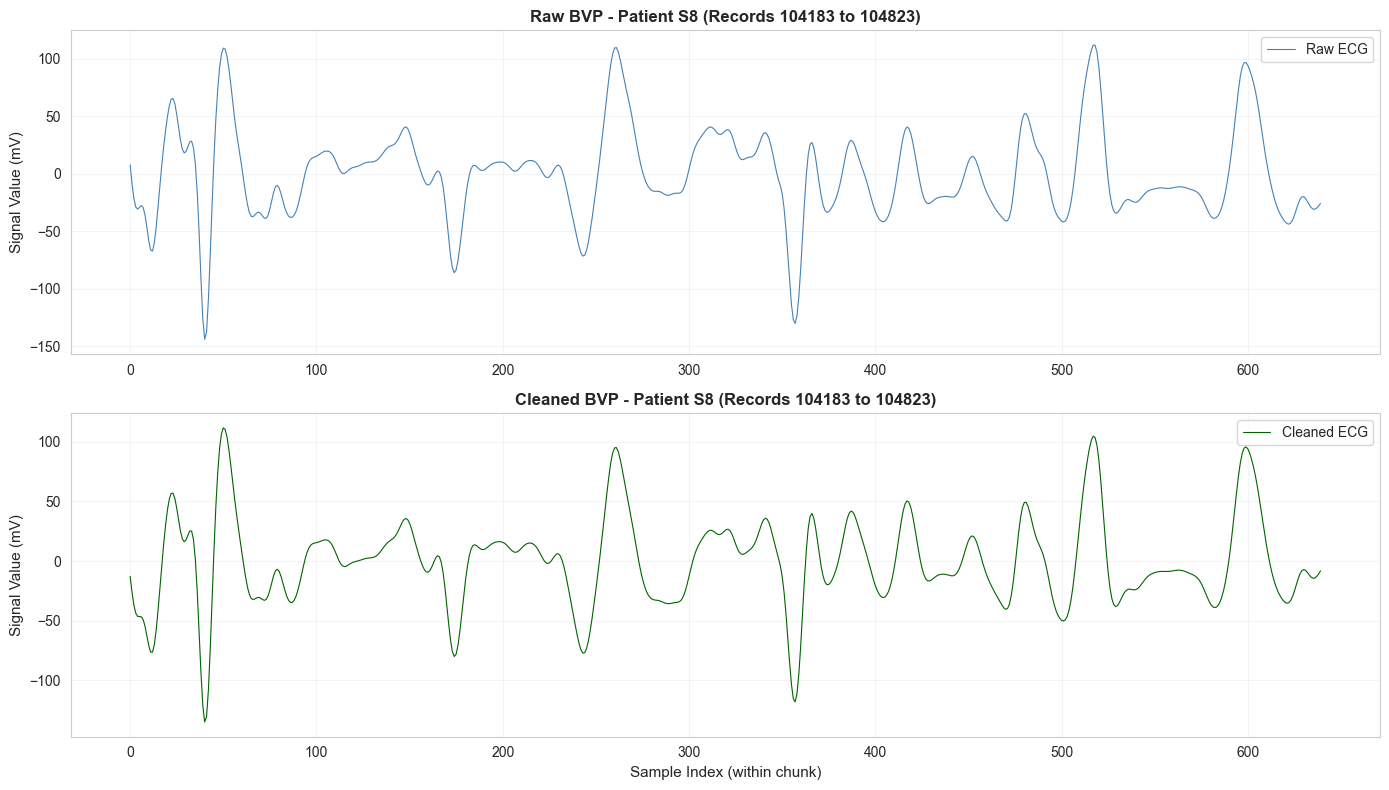

  Raw BVP - Mean: -0.4090, Std: 39.1464, Min: -144.1600, Max: 111.7800
  Cleaned BVP - Mean: -0.6163, Std: 37.4950, Min: -134.8516, Max: 111.6092

Processing S9...


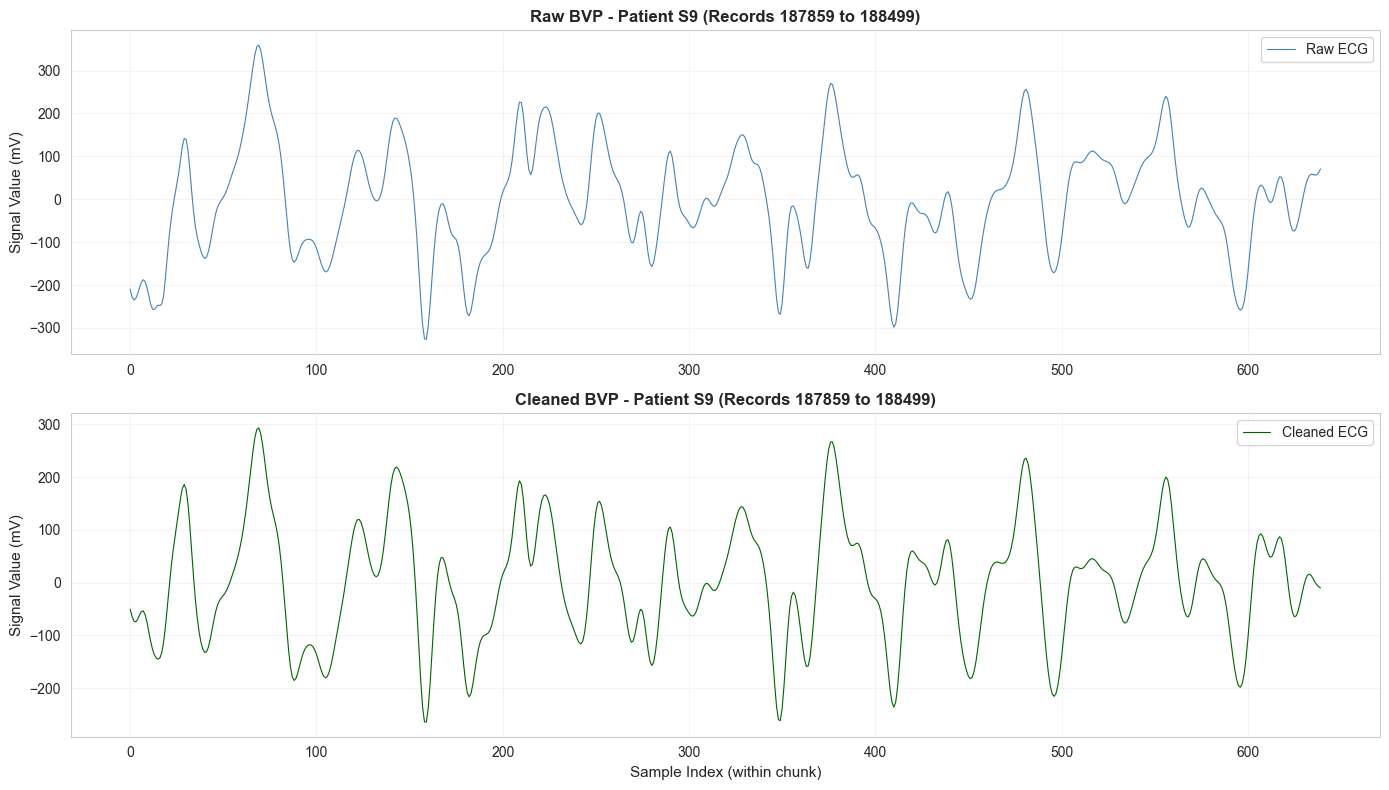

  Raw BVP - Mean: -3.5282, Std: 129.1863, Min: -326.4900, Max: 359.3600
  Cleaned BVP - Mean: 0.0347, Std: 110.8595, Min: -264.1836, Max: 293.3844

Processing S10...


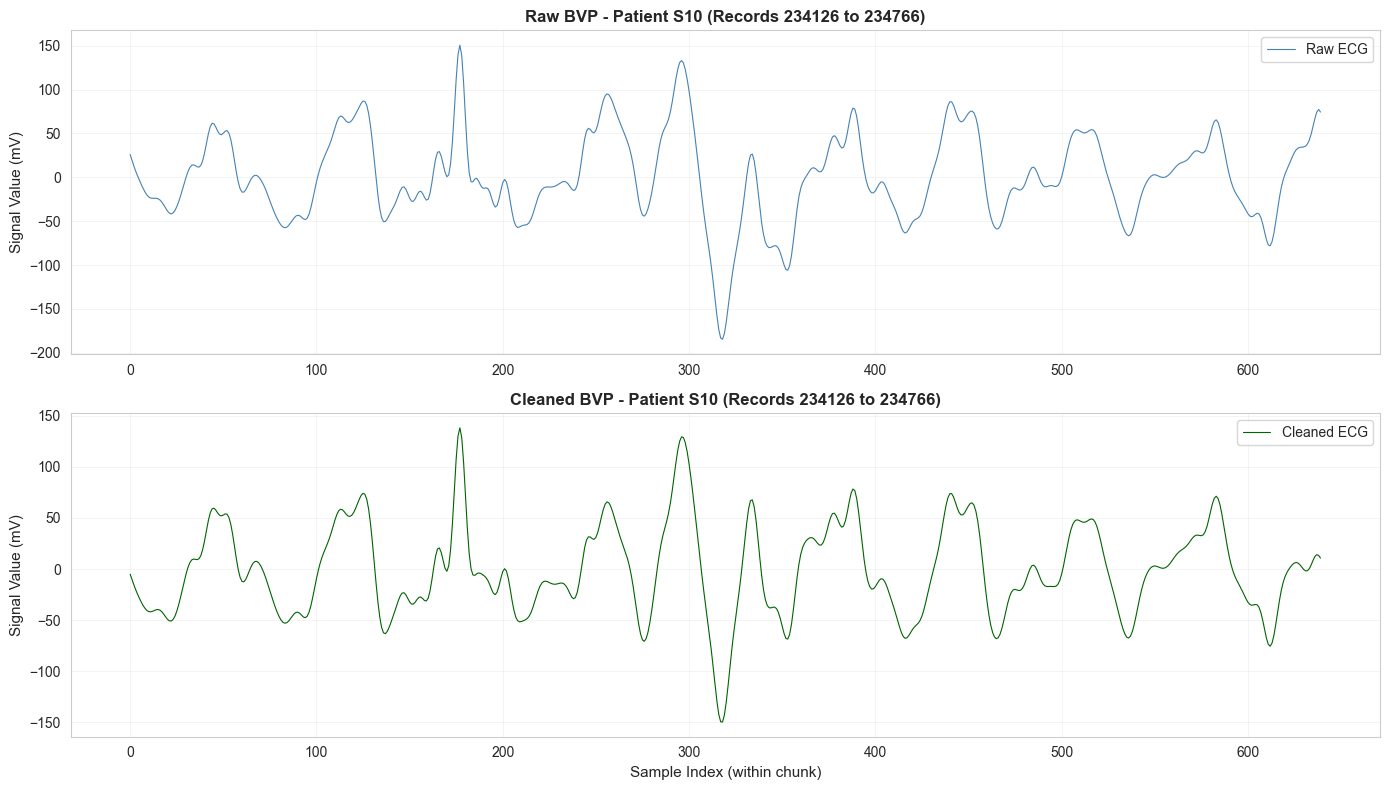

  Raw BVP - Mean: 1.0062, Std: 50.2343, Min: -184.5700, Max: 150.6100
  Cleaned BVP - Mean: -1.0717, Std: 45.0785, Min: -149.7710, Max: 138.2313

Processing S11...


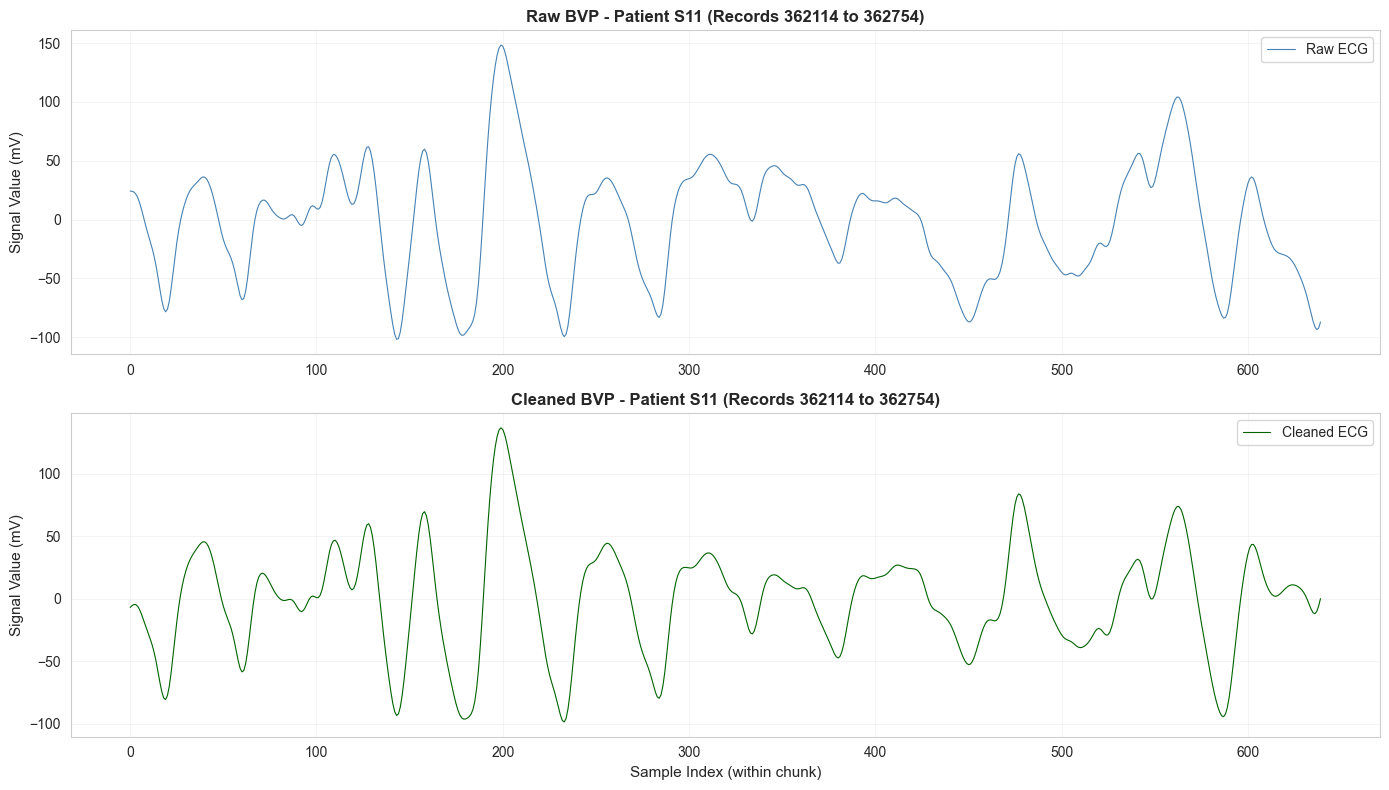

  Raw BVP - Mean: -2.0132, Std: 48.4987, Min: -101.6800, Max: 148.2800
  Cleaned BVP - Mean: -0.8912, Std: 42.5330, Min: -98.7340, Max: 136.7223

Processing S12...


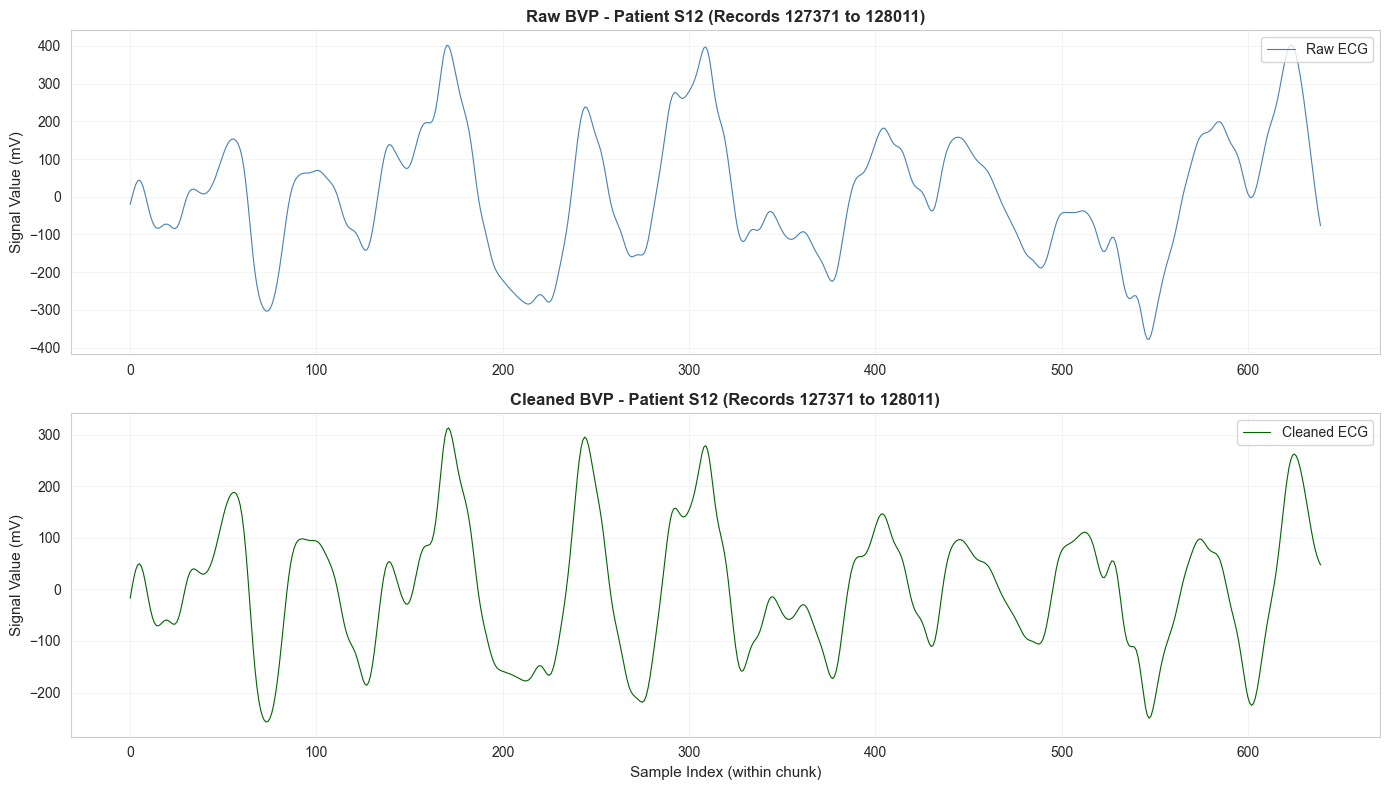

  Raw BVP - Mean: 5.0966, Std: 167.1245, Min: -377.7400, Max: 401.7100
  Cleaned BVP - Mean: 0.1121, Std: 124.8654, Min: -257.2469, Max: 313.3094

Processing S13...


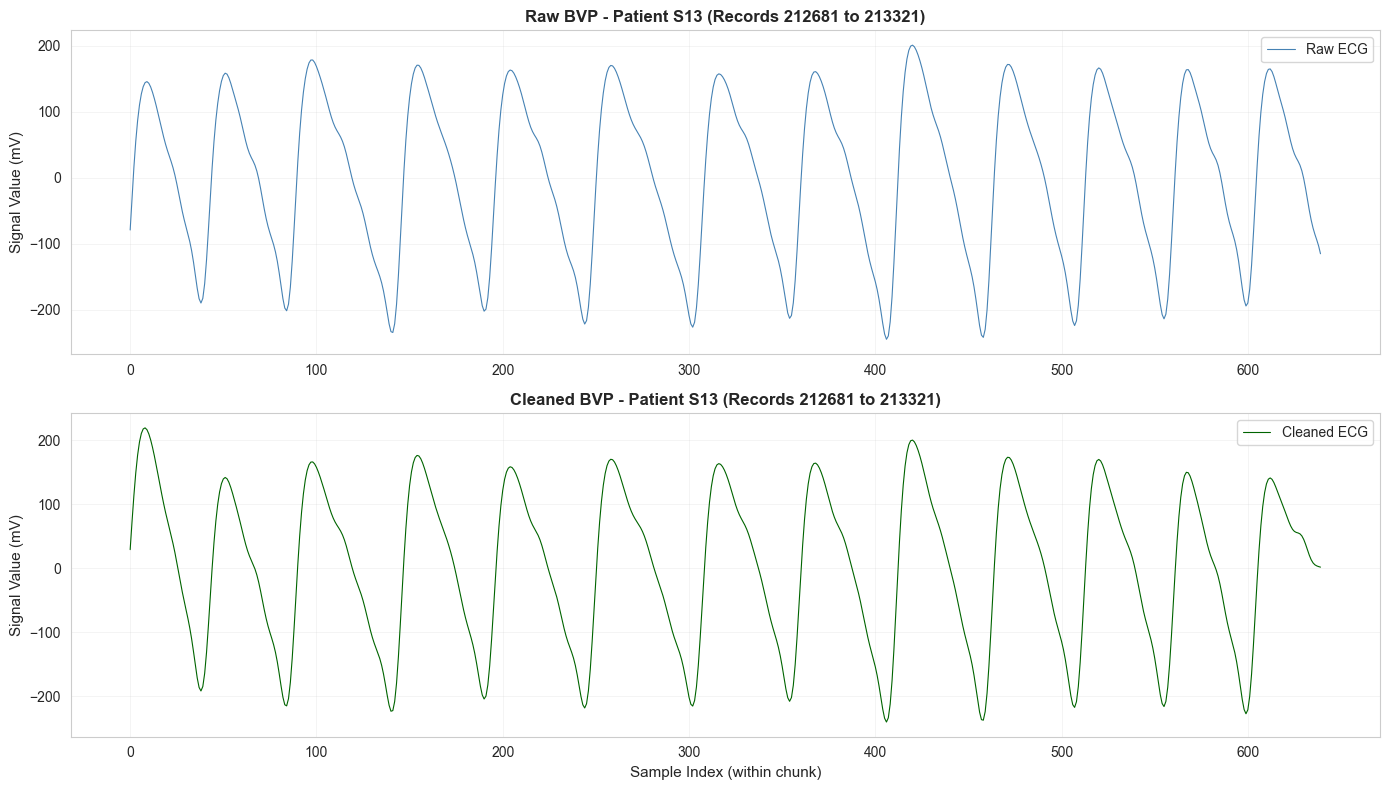

  Raw BVP - Mean: 2.4363, Std: 119.8174, Min: -244.4600, Max: 201.0800
  Cleaned BVP - Mean: 3.6825, Std: 121.0084, Min: -239.9575, Max: 219.1978

Processing S14...


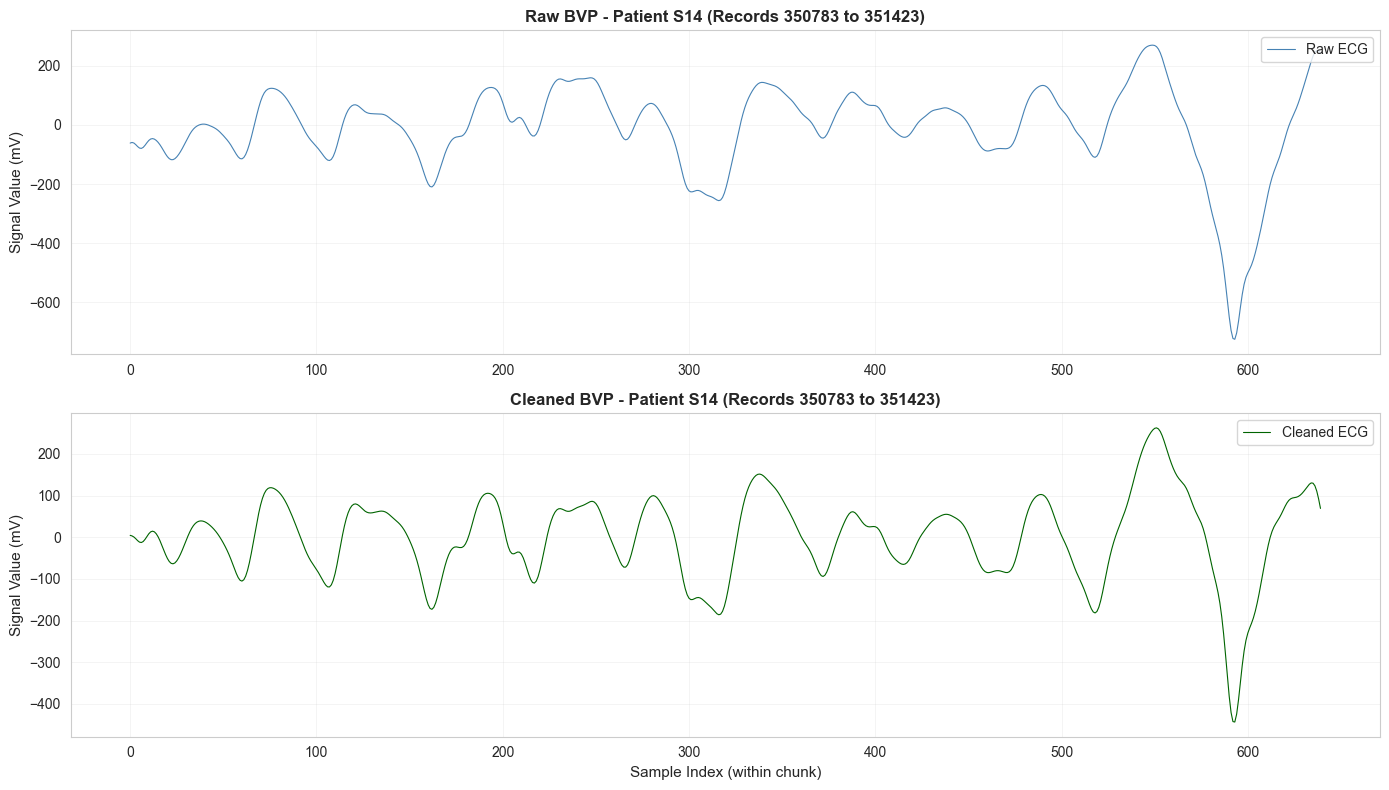

  Raw BVP - Mean: -13.3313, Std: 150.5809, Min: -724.5200, Max: 269.3400
  Cleaned BVP - Mean: -0.5070, Std: 102.4407, Min: -443.4613, Max: 262.5376

Processing S15...


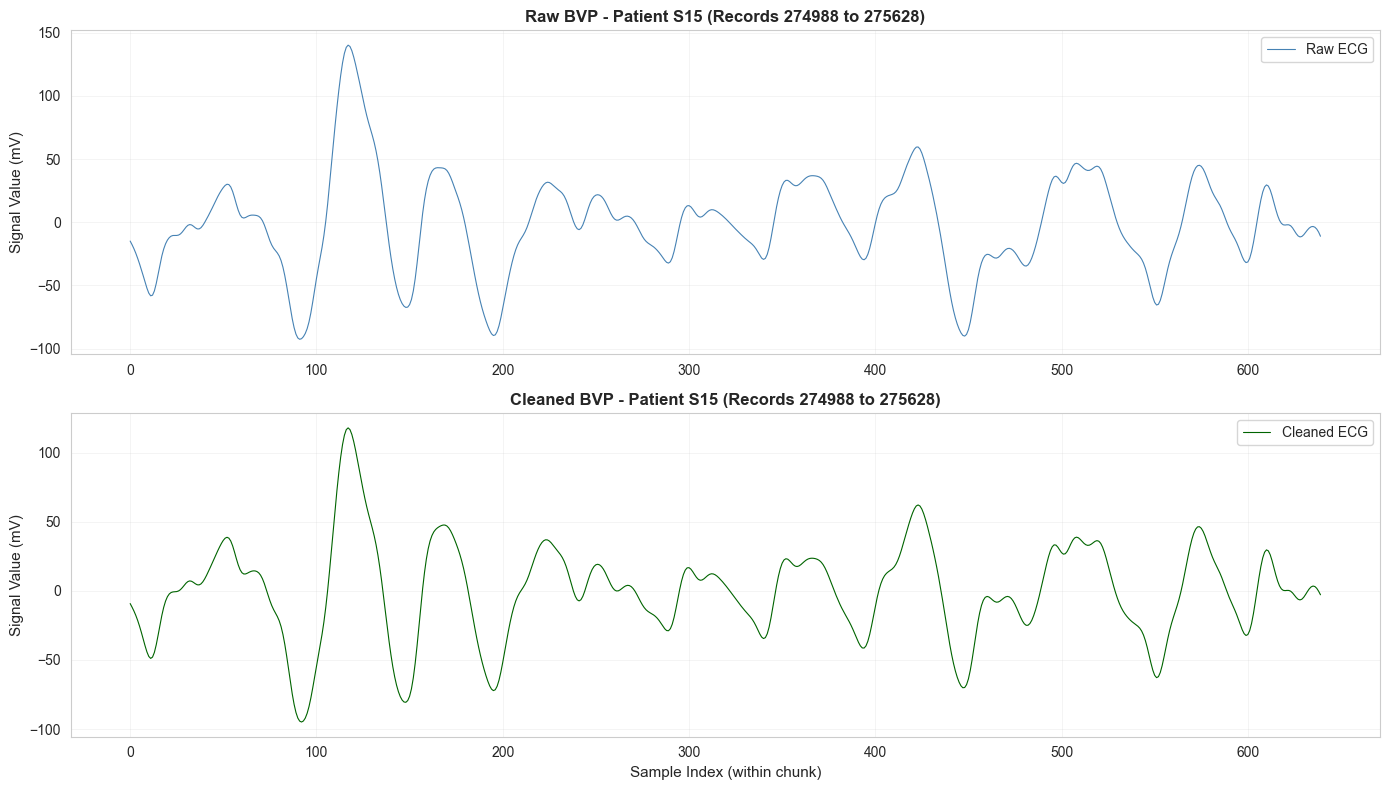

  Raw BVP - Mean: -1.2276, Std: 38.9675, Min: -92.6500, Max: 140.1300
  Cleaned BVP - Mean: -0.4084, Std: 35.0367, Min: -94.9250, Max: 117.9170

All comparisons displayed ✓


In [35]:
# Compare raw BVP vs cleaned BVP side by side
print("Comparing raw vs cleaned BVP for all patients...")
print("=" * 70)

for patient_id, data in patient_chunks.items():
    print(f"\nProcessing {patient_id}...")

    # Extract raw BVP values
    raw_bvp = data['chunk'].iloc[:, 0].values

    # Clean BVP with neurokit2
    cleaned_bvp = nk.ppg_clean(raw_bvp, sampling_rate=64)

    # Create side-by-side comparison plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Plot raw bvp
    axes[0].plot(raw_bvp, linewidth=0.8, color='steelblue', label='Raw ECG')
    axes[0].set_title(f'Raw BVP - Patient {patient_id} '
                      f'(Records {data["start_idx"]} to {data["end_idx"]})',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Signal Value (mV)', fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper right')

    # Plot cleaned bvp
    axes[1].plot(cleaned_bvp, linewidth=0.8, color='darkgreen', label='Cleaned ECG')
    axes[1].set_title(f'Cleaned BVP - Patient {patient_id} '
                      f'(Records {data["start_idx"]} to {data["end_idx"]})',
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Sample Index (within chunk)', fontsize=11)
    axes[1].set_ylabel('Signal Value (mV)', fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # Print some statistics
    print(f"  Raw BVP - Mean: {np.mean(raw_bvp):.4f}, Std: {np.std(raw_bvp):.4f}, "
          f"Min: {np.min(raw_bvp):.4f}, Max: {np.max(raw_bvp):.4f}")
    print(f"  Cleaned BVP - Mean: {np.mean(cleaned_bvp):.4f}, Std: {np.std(cleaned_bvp):.4f}, "
          f"Min: {np.min(cleaned_bvp):.4f}, Max: {np.max(cleaned_bvp):.4f}")

print("\n" + "=" * 70)
print("All comparisons displayed ✓")